In [1]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install graphviz

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import json
import os
import re

In [4]:
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.ensemble import RandomForestClassifier
from IPython.display import display
from sklearn.tree import export_graphviz
import graphviz
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

## Pre-processing

Cleaning snp matrix

In [7]:
snp_df = pd.read_csv("maf_prop_snp_matrix.csv")

# Separate id for cleaning
id_col = snp_df['id']
data = snp_df.drop(columns=['id'])

# Drop cols where all 0 
non_zero_cols = (data.iloc[1:] != 0).any(axis=0)
zero_cols = non_zero_cols[~non_zero_cols].index.tolist()
print(f"⚠️ Columns with all zeros: {len(zero_cols)}")
data = data.loc[:, non_zero_cols]

# Drop cols with null or empty string
has_null = data.isnull().any()
has_empty_str = (data == '').any()
missing_cols = has_null | has_empty_str
print(f"⚠️ Columns with null or empty string values: {missing_cols.sum()}")
no_missing_cols = ~missing_cols
data = data.loc[:, no_missing_cols]


final_df = pd.concat([id_col, data], axis=1)

final_df.to_csv("input_snps.csv", index=False)
print(f"✅ input_snps.csv created.\nShape: {final_df.shape}")


⚠️ Columns with all zeros: 0
⚠️ Columns with null or empty string values: 0
✅ input_snps.csv created.
Shape: (400, 102)


Combining input_snp with country and drug resistance pDST results for INH, RIF, PZA, and STM

In [10]:
snp_df = pd.read_csv("input_snps.csv")

# Remove .vcf
snp_df["id"] = snp_df["id"].str.replace(".vcf", "", regex=False)

xl = pd.ExcelFile("master_data.xlsx")
meta_df = xl.parse("All", header=1)[["isolate name", "ena_run", "country"]]

target_drugs = ["ISONIAZID", "RIFAMPICIN", "ETHAMBUTOL", "STREPTOMYCIN"]

for drug in target_drugs:
    if drug in xl.sheet_names:
        drug_df = xl.parse(drug)
        colname = f"{drug.lower()}_resistance"
        drug_df = drug_df.rename(columns={"resistance phenotype (pDST)": colname})
        drug_df[colname] = drug_df[colname].map({"R": 1, "S": 0})
        meta_df = meta_df.merge(drug_df[["isolate name", colname]], on="isolate name", how="left")
    else:
        print(f"⚠️ Sheet not found: {drug}")

missing_ids = set(snp_df["id"]) - set(meta_df["ena_run"])
for mid in missing_ids:
    print(f"⛔ Not found in master data excel: {mid}")

final_df = snp_df.merge(meta_df, left_on="id", right_on="ena_run", how="inner")
final_df = final_df.drop(columns=["ena_run", "isolate name"])

final_df.to_csv("0_input.csv", index=False)
print(f"✅ 0_input.csv created.\nShape: {final_df.shape}")

⛔ Not found in master data excel: ERR3794472
⛔ Not found in master data excel: ERR2200091
⛔ Not found in master data excel: ERR2199933
⛔ Not found in master data excel: ERR3794420
⛔ Not found in master data excel: ERR2199934
⛔ Not found in master data excel: ERR4872232
⛔ Not found in master data excel: ERR046965
⛔ Not found in master data excel: ERR550776
⛔ Not found in master data excel: ERR3794505
⛔ Not found in master data excel: ERR038257
⛔ Not found in master data excel: ERR2200119
⛔ Not found in master data excel: ERR2200096
⛔ Not found in master data excel: ERR2199999
⛔ Not found in master data excel: ERR3794356
⛔ Not found in master data excel: ERR046771
⛔ Not found in master data excel: ERR3794550
⛔ Not found in master data excel: ERR046937
⛔ Not found in master data excel: ERR046847
⛔ Not found in master data excel: ERR3794427
⛔ Not found in master data excel: ERR046840
✅ 0_input.csv created.
Shape: (380, 107)


In [11]:
print("\n")
print(final_df.head())



          id  Chromosome_6112_G_C  Chromosome_7362_G_C  Chromosome_7582_A_G  \
0  ERR067635                    0                    1                    1   
1  ERR067660                    0                    1                    0   
2  ERR067667                    0                    1                    0   
3  ERR067717                    0                    1                    0   
4  ERR067742                    0                    1                    0   

   Chromosome_7585_G_C  Chromosome_8452_C_T  Chromosome_9143_T_C  \
0                    1                    0                    0   
1                    1                    0                    0   
2                    1                    0                    0   
3                    1                    0                    0   
4                    1                    0                    0   

   Chromosome_9304_G_A  Chromosome_13298_G_C  Chromosome_13460_A_G  ...  \
0                    1                 

In [12]:
def extract_lineage(id_):
    json_path = os.path.join("results", f"{id_}.results.json")
    if not os.path.exists(json_path):
        print(f"⛔ Lineage file not found: {json_path}")
        return None
    
    try:
        with open(json_path, "r") as f:
            data = json.load(f)
            if "lineage" in data and isinstance(data["lineage"], list) and data["lineage"]:
                lineage_str = data["lineage"][0]["lineage"]
                # Extract the number using regex
                match = re.search(r'\d+', lineage_str)
                if match:
                    return int(match.group())  # Return as int (optional)
                else:
                    print(f"⚠️ Could not extract number from lineage string: {lineage_str}")
            else:
                print(f"⚠️ No lineage data in: {json_path}")
    except Exception as e:
        print(f"⚠️ Error reading {json_path}: {e}")
    return None

final_df["lineage"] = final_df["id"].apply(extract_lineage)

final_df.to_csv("0_input_with_lineage.csv", index=False)
print(f"✅ 0_input_with_lineage.csv created.\nShape: {final_df.shape}")

⚠️ No lineage data in: results\ERR2516384.results.json
✅ 0_input_with_lineage.csv created.
Shape: (380, 108)


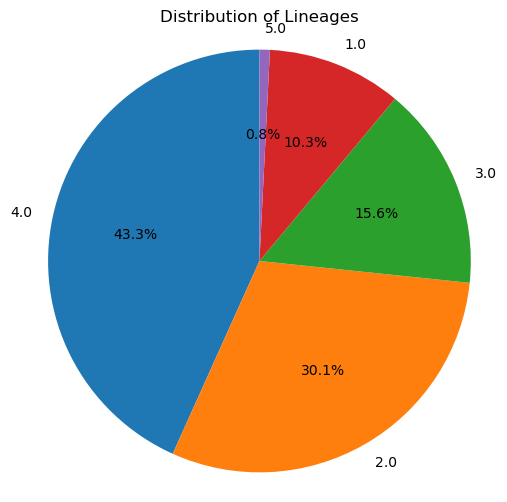

In [13]:
# Drop NaNs (if any) for clean visualization
lineage_counts = final_df['lineage'].dropna().value_counts()

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(lineage_counts, labels=lineage_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Lineages')
plt.axis('equal')  # Equal aspect ratio ensures pie is a circle.
plt.show()

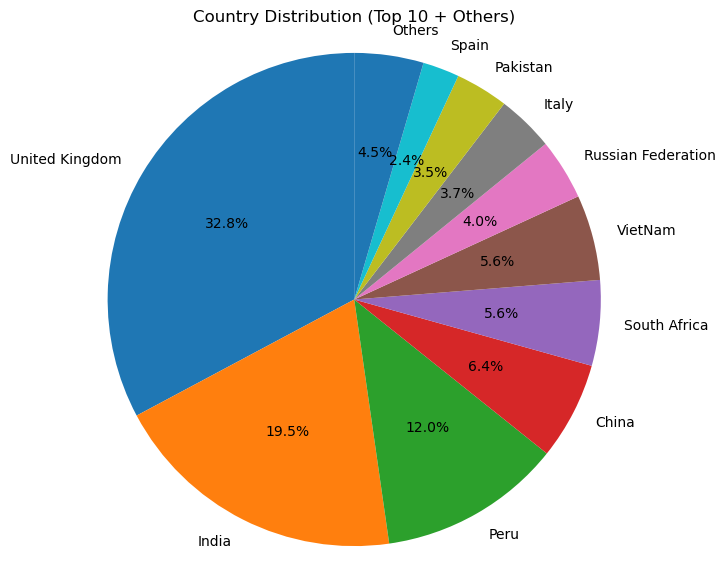

In [14]:
# Drop NaNs (optional)
country_counts = final_df['country'].dropna().value_counts()

# Optional: show only top N countries and group the rest as "Others"
top_n = 10
top_countries = country_counts[:top_n]
others = country_counts[top_n:].sum()
if others > 0:
    top_countries["Others"] = others

# Plot pie chart
plt.figure(figsize=(7, 7))
plt.pie(top_countries, labels=top_countries.index, autopct='%1.1f%%', startangle=90)
plt.title('Country Distribution (Top 10 + Others)')
plt.axis('equal')
plt.show()


## Random Forest

Source: https://www.datacamp.com/tutorial/random-forests-classifier-python

### Isoniazid resistance prediction

In [19]:
input_df = pd.read_csv("0_input_with_lineage.csv")
input_df = input_df.drop(columns=['id'], errors='ignore')

INH_na = input_df['isoniazid_resistance'].isna().sum()
print("Missing values before drop:", INH_na)

# drop rows where resistance is missing
input_df = input_df.dropna(subset=['isoniazid_resistance'])
input_df = pd.get_dummies(input_df, columns=['country'])

Missing values before drop: 55


In [20]:
columns_to_drop = ['rifampicin_resistance', 'ethambutol_resistance', 'streptomycin_resistance']
input_df = input_df.drop(columns=columns_to_drop, errors='ignore')

# convert float to int
input_df['isoniazid_resistance'] = input_df['isoniazid_resistance'].astype(int)

In [21]:
print("Shape after drop:", input_df.shape)

Shape after drop: (325, 119)


#### Training

In [24]:
X_with_lineage = input_df.drop(columns=['isoniazid_resistance'])
X_without_lineage = X_with_lineage.drop(columns=[col for col in X_with_lineage.columns if 'lineage' in col.lower()], errors='ignore')
y = input_df['isoniazid_resistance']

print("Shape of X_with_lineage (features):", X_with_lineage.shape)
print("Shape of X_without_lineage (features):", X_without_lineage.shape)
print("Shape of y (target):", y.shape)

Shape of X_with_lineage (features): (325, 118)
Shape of X_without_lineage (features): (325, 117)
Shape of y (target): (325,)


In [25]:
X_train_wi, X_test_wi, y_train, y_test = train_test_split(X_with_lineage, y, test_size=0.2, random_state=42, stratify=y)
X_train_wo, X_test_wo, _, _ = train_test_split(X_without_lineage, y, test_size=0.2, random_state=42, stratify=y)

In [26]:
print("=== Original Feature Shapes ===")
print("Shape of X_with_lineage:", X_with_lineage.shape)
print("Shape of X_without_lineage:", X_without_lineage.shape)
print("Shape of y (target):", y.shape)

print("\n=== Train/Test Split Shapes (without lineage) ===")
print("Training feature shape:", X_train_wo.shape)
print("Testing feature shape:", X_test_wo.shape)

print("\n=== Train/Test Split Shapes (with lineage) ===")
print("Training feature shape:", X_train_wi.shape)
print("Testing feature shape:", X_test_wi.shape)

=== Original Feature Shapes ===
Shape of X_with_lineage: (325, 118)
Shape of X_without_lineage: (325, 117)
Shape of y (target): (325,)

=== Train/Test Split Shapes (without lineage) ===
Training feature shape: (260, 117)
Testing feature shape: (65, 117)

=== Train/Test Split Shapes (with lineage) ===
Training feature shape: (260, 118)
Testing feature shape: (65, 118)


In [27]:
# === Cross-validation WITH lineage ===
rf_wi = RandomForestClassifier(random_state=42)
scores_wi = cross_validate(rf_wi, X_with_lineage, y, cv=5,
                           scoring=['accuracy', 'precision', 'recall', 'f1'])

# === Cross-validation WITHOUT lineage ===
rf_wo = RandomForestClassifier(random_state=42)
scores_wo = cross_validate(rf_wo, X_without_lineage, y, cv=5,
                           scoring=['accuracy', 'precision', 'recall', 'f1'])

# === Collect CV Results ===
cv_results = []

cv_results.append({
    "Drug": "INH",
    "Model": "With Lineage",
    "Accuracy": np.mean(scores_wi['test_accuracy']),
    "Precision": np.mean(scores_wi['test_precision']),
    "Recall": np.mean(scores_wi['test_recall']),
    "F1 Score": np.mean(scores_wi['test_f1']),
})

cv_results.append({
    "Drug": "INH",
    "Model": "Without Lineage",
    "Accuracy": np.mean(scores_wo['test_accuracy']),
    "Precision": np.mean(scores_wo['test_precision']),
    "Recall": np.mean(scores_wo['test_recall']),
    "F1 Score": np.mean(scores_wo['test_f1']),
})

In [28]:
# === Test WITH lineage ===
rf_wi_test = RandomForestClassifier(random_state=42)
rf_wi_test.fit(X_train_wi, y_train)
y_pred_wi = rf_wi_test.predict(X_test_wi)

cv_results.append({
    "Drug": "INH",
    "Model": "With Lineage (Test)",
    "Accuracy": accuracy_score(y_test, y_pred_wi),
    "Precision": precision_score(y_test, y_pred_wi),
    "Recall": recall_score(y_test, y_pred_wi),
    "F1 Score": f1_score(y_test, y_pred_wi),
})

# === Test WITHOUT lineage ===
rf_wo_test = RandomForestClassifier(random_state=42)
rf_wo_test.fit(X_train_wo, y_train)
y_pred_wo = rf_wo_test.predict(X_test_wo)

cv_results.append({
    "Drug": "INH",
    "Model": "Without Lineage (Test)",
    "Accuracy": accuracy_score(y_test, y_pred_wo),
    "Precision": precision_score(y_test, y_pred_wo),
    "Recall": recall_score(y_test, y_pred_wo),
    "F1 Score": f1_score(y_test, y_pred_wo),
})


#### Performance metrics

In [30]:
results_df = pd.DataFrame(cv_results)
results_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']] = results_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']].round(2)
results_df

,Drug,Model,Accuracy,Precision,Recall,F1 Score
0,INH,With Lineage,0.90,0.92,0.78,0.84
1,INH,Without Lineage,0.90,0.94,0.78,0.85
2,INH,With Lineage (Test),0.89,1.00,0.70,0.82
3,INH,Without Lineage (Test),0.89,0.94,0.74,0.83


Confusion Matrix - With Lineage (Test)


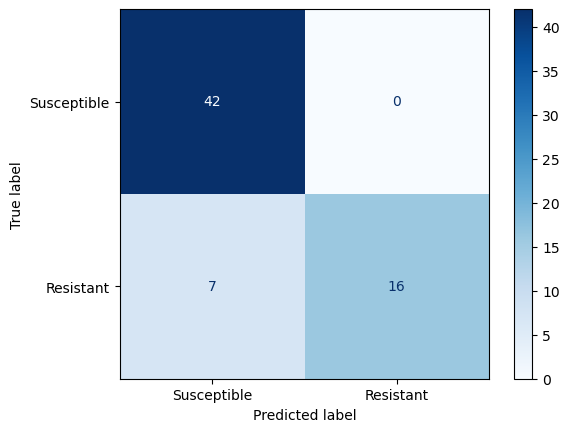

Confusion Matrix - Without Lineage (Test)


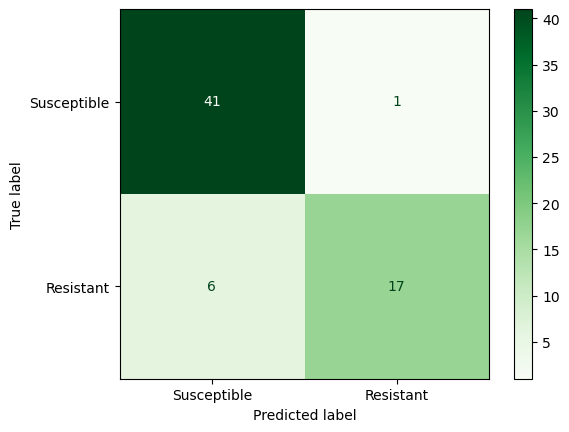

In [31]:
# === Confusion Matrix for With Lineage ===
cm_wi = confusion_matrix(y_test, y_pred_wi)
disp_wi = ConfusionMatrixDisplay(confusion_matrix=cm_wi, display_labels=["Susceptible", "Resistant"])
print("Confusion Matrix - With Lineage (Test)")
disp_wi.plot(cmap="Blues")
plt.grid(False)
plt.show()

# === Confusion Matrix for Without Lineage ===
cm_wo = confusion_matrix(y_test, y_pred_wo)
disp_wo = ConfusionMatrixDisplay(confusion_matrix=cm_wo, display_labels=["Susceptible", "Resistant"])
print("Confusion Matrix - Without Lineage (Test)")
disp_wo.plot(cmap="Greens")
plt.grid(False)
plt.show()


#### Tree visualization

=== Decision Trees from Random Forest (With Lineage) ===


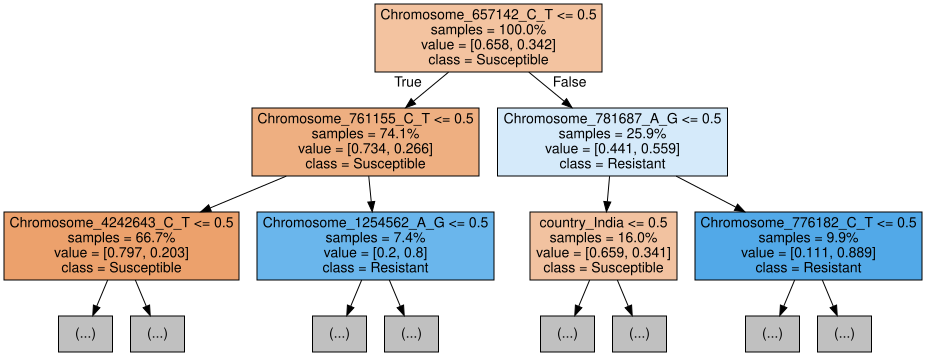

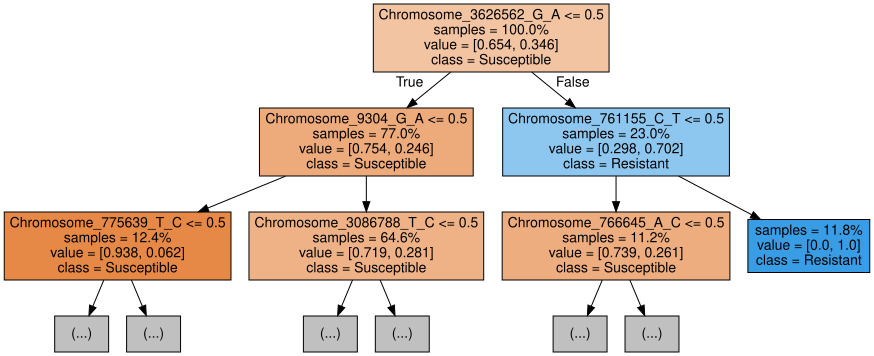

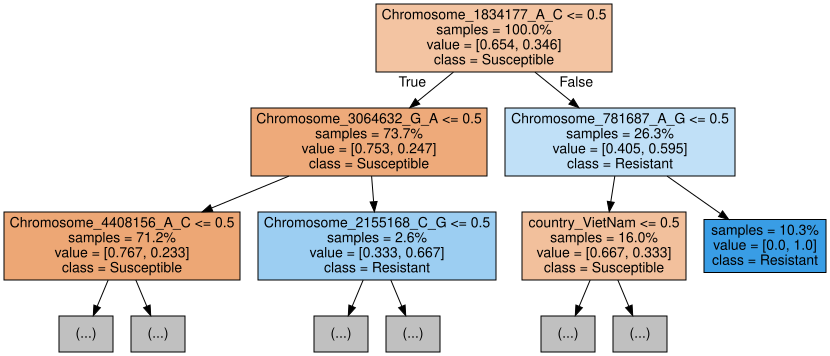


=== Decision Trees from Random Forest (Without Lineage) ===


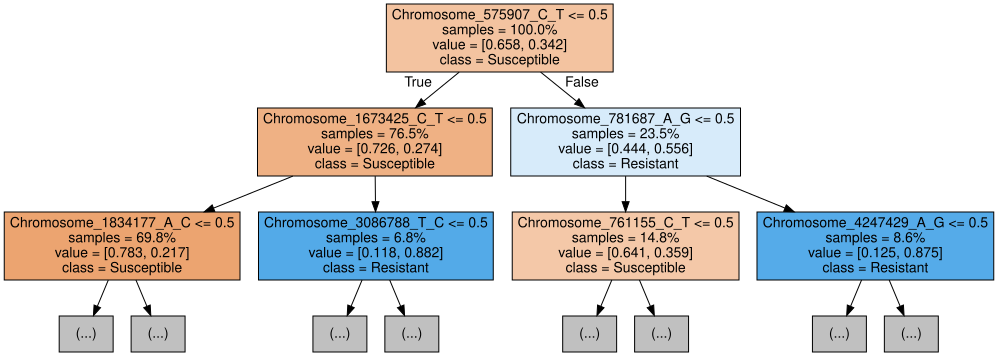

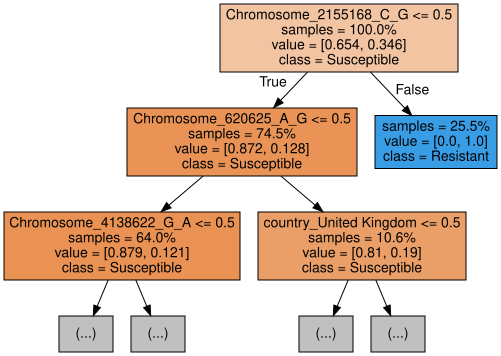

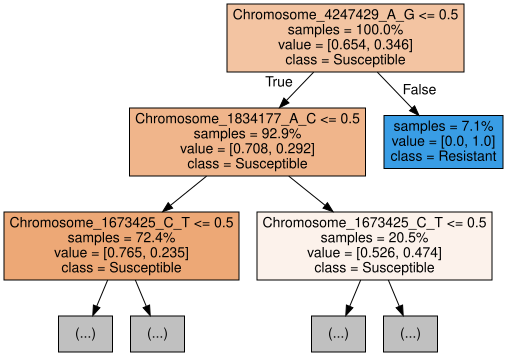

In [35]:
# === Visualize 3 Trees from Random Forest (With Lineage)
print("=== Decision Trees from Random Forest (With Lineage) ===")
for i in range(3):
    tree = rf_wi_test.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X_train_wi.columns,
                               filled=True,
                               max_depth=2,
                               impurity=False,
                               proportion=True,
                               class_names=["Susceptible", "Resistant"])
    graph = graphviz.Source(dot_data)
    display(graph)
    graph.render(f"tree_with_lineage_{i}", format="png", cleanup=True)

# === Visualize 3 Trees from Random Forest (Without Lineage)
print("\n=== Decision Trees from Random Forest (Without Lineage) ===")
for i in range(3):
    tree = rf_wo_test.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X_train_wo.columns,
                               filled=True,
                               max_depth=2,
                               impurity=False,
                               proportion=True,
                               class_names=["Susceptible", "Resistant"])
    graph = graphviz.Source(dot_data)
    display(graph)
    graph.render(f"tree_without_lineage_{i}", format="png", cleanup=True)


#### Feature importance

In [37]:
# === Feature Importances: With Lineage ===
importances_wi = rf_wi_test.feature_importances_
features_wi = X_train_wi.columns

fi_df_wi = pd.DataFrame({
    'Feature': features_wi,
    'Importance': importances_wi
}).sort_values(by='Importance', ascending=False)

print("=== Feature Importances: With Lineage ===")
print(fi_df_wi)

=== Feature Importances: With Lineage ===
                   Feature  Importance
53  Chromosome_2155168_C_G    0.340302
21   Chromosome_761155_C_T    0.136851
45  Chromosome_1673425_C_T    0.112712
35   Chromosome_781687_A_G    0.049183
87  Chromosome_4247429_A_G    0.038432
..                     ...         ...
69  Chromosome_3624486_T_C    0.000120
30   Chromosome_775639_T_C    0.000041
34   Chromosome_781395_T_C    0.000004
1      Chromosome_7362_G_C    0.000000
43  Chromosome_1471659_C_T    0.000000

[118 rows x 2 columns]


C:\Users\hialo\AppData\Local\Temp\ipykernel_28072\2906224505.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df_wi.head(10), palette='Blues_r')


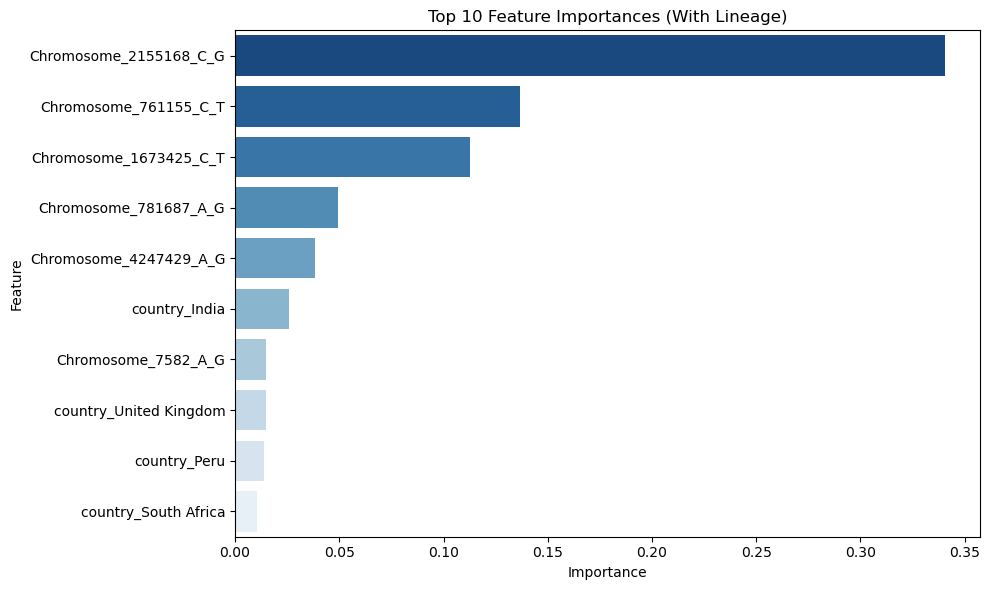

In [38]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df_wi.head(10), palette='Blues_r')
plt.title('Top 10 Feature Importances (With Lineage)')
plt.tight_layout()
plt.show()

In [39]:
threshold = 1e-3
near_zero_wi = fi_df_wi[fi_df_wi['Importance'] < threshold]['Feature'].tolist()

print(f"{len(near_zero_wi)} features have importance < {threshold} (With Lineage):\n")
for i, feature in enumerate(near_zero_wi, 1):
    print(f"{i}. {feature}")

42 features have importance < 0.001 (With Lineage):

1. Chromosome_1417554_G_C
2. country_Belgium
3. Chromosome_4044872_G_A
4. Chromosome_2518076_C_T
5. Chromosome_1254562_A_G
6. Chromosome_4242075_G_A
7. Chromosome_800357_C_A
8. Chromosome_2222308_T_C
9. Chromosome_4328492_G_A
10. country_Spain
11. Chromosome_4138622_G_A
12. Chromosome_763884_C_T
13. Chromosome_4269606_A_G
14. Chromosome_4249408_G_A
15. Chromosome_1417019_C_T
16. Chromosome_4247646_A_C
17. Chromosome_4407873_C_A
18. Chromosome_734116_T_C
19. Chromosome_1853974_C_T
20. Chromosome_13460_A_G
21. Chromosome_2518132_C_T
22. Chromosome_575679_A_G
23. Chromosome_2782498_G_A
24. Chromosome_1417793_G_A
25. Chromosome_4040517_A_G
26. Chromosome_4338603_G_A
27. Chromosome_8452_C_T
28. Chromosome_2223293_T_C
29. Chromosome_2726051_G_A
30. Chromosome_657578_A_G
31. Chromosome_4241042_A_G
32. country_Nepal
33. Chromosome_763886_C_A
34. Chromosome_2062922_T_C
35. Chromosome_6112_G_C
36. Chromosome_4269387_T_G
37. Chromosome_13298_G_

In [40]:
# === Feature Importances: Without Lineage ===
importances_wo = rf_wo_test.feature_importances_
features_wo = X_train_wo.columns

fi_df_wo = pd.DataFrame({
    'Feature': features_wo,
    'Importance': importances_wo
}).sort_values(by='Importance', ascending=False)

print("\n=== Feature Importances: Without Lineage ===")
print(fi_df_wo)


=== Feature Importances: Without Lineage ===
                   Feature  Importance
53  Chromosome_2155168_C_G    0.325636
21   Chromosome_761155_C_T    0.151229
45  Chromosome_1673425_C_T    0.116082
35   Chromosome_781687_A_G    0.045812
87  Chromosome_4247429_A_G    0.041981
..                     ...         ...
81  Chromosome_4241042_A_G    0.000071
34   Chromosome_781395_T_C    0.000009
30   Chromosome_775639_T_C    0.000009
1      Chromosome_7362_G_C    0.000000
43  Chromosome_1471659_C_T    0.000000

[117 rows x 2 columns]


C:\Users\hialo\AppData\Local\Temp\ipykernel_28072\3033769339.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df_wo.head(10), palette='Greens_r')


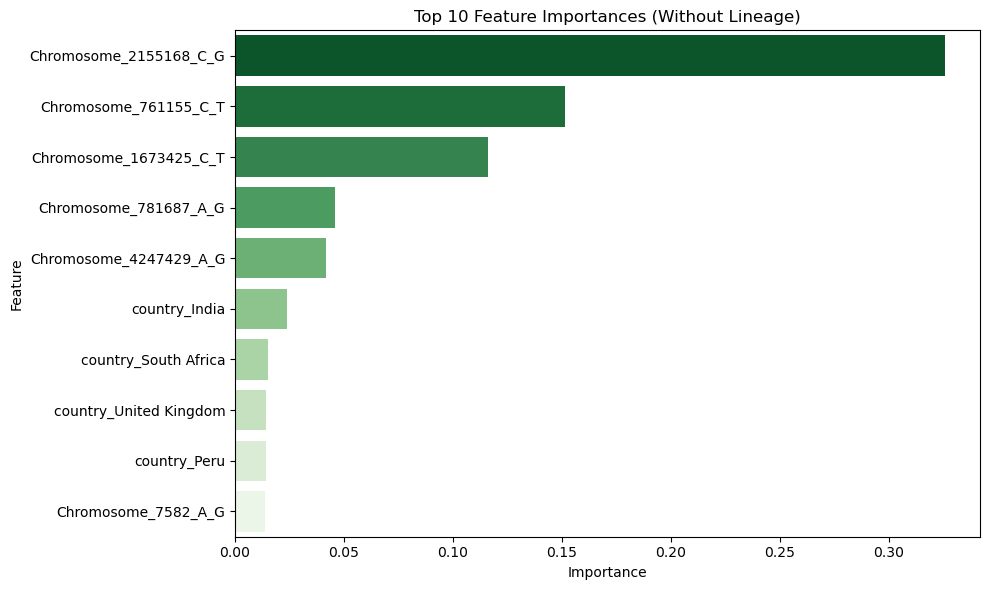

In [41]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df_wo.head(10), palette='Greens_r')
plt.title('Top 10 Feature Importances (Without Lineage)')
plt.tight_layout()
plt.show()

In [42]:
threshold = 1e-3
near_zero_wo = fi_df_wo[fi_df_wo['Importance'] < threshold]['Feature'].tolist()

print(f"{len(near_zero_wo)} features have importance < {threshold} (Without Lineage):\n")
for i, feature in enumerate(near_zero_wo, 1):
    print(f"{i}. {feature}")

43 features have importance < 0.001 (Without Lineage):

1. Chromosome_800219_T_C
2. Chromosome_762434_T_G
3. country_Ethiopia
4. Chromosome_9143_T_C
5. Chromosome_4242075_G_A
6. Chromosome_4138377_A_G
7. Chromosome_4269387_T_G
8. Chromosome_763886_C_A
9. country_Spain
10. Chromosome_657142_C_T
11. Chromosome_13460_A_G
12. Chromosome_4328492_G_A
13. Chromosome_734116_T_C
14. Chromosome_2518132_C_T
15. Chromosome_575679_A_G
16. Chromosome_1417554_G_C
17. Chromosome_763884_C_T
18. Chromosome_4240671_C_T
19. Chromosome_4245969_C_T
20. Chromosome_4338603_G_A
21. Chromosome_800357_C_A
22. Chromosome_4247646_A_C
23. Chromosome_2223293_T_C
24. Chromosome_2222308_T_C
25. Chromosome_4138622_G_A
26. Chromosome_3624486_T_C
27. Chromosome_2062922_T_C
28. Chromosome_6112_G_C
29. Chromosome_4407873_C_A
30. Chromosome_1417019_C_T
31. Chromosome_1853974_C_T
32. Chromosome_4269606_A_G
33. Chromosome_4040517_A_G
34. country_Nepal
35. Chromosome_13298_G_C
36. Chromosome_657578_A_G
37. Chromosome_8452_C_T


#### Hyperparameter Tuning

Source: https://www.geeksforgeeks.org/machine-learning/random-forest-hyperparameter-tuning-in-python/

In [172]:
# === With lineage ===
X_train_tune = X_train_wi
y_train_tune = y_train

# === Hyperparameter Grid ===
param_grid = {
    'n_estimators': [300, 500, 800, 1000, 1200], 
    'max_depth': [None, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True]
}

# === Grid Search with Cross-Validation ===
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1  # Use all CPU cores
)

grid_search.fit(X_train_tune, y_train_tune)

# === Results ===
print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)
print("Best Estimator:\n", grid_search.best_estimator_)


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best Parameters: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 1000}
Best CV Accuracy: 0.9423076923076923
Best Estimator:
 RandomForestClassifier(n_estimators=1000, random_state=42)


In [175]:
# === With lineage ===
X_train_tune = X_train_wo
y_train_tune = y_train

# === Hyperparameter Grid ===
param_grid = {
    'n_estimators': [300, 500, 800, 1000, 1200], 
    'max_depth': [None, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True]
}

# === Grid Search with Cross-Validation ===
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1  # Use all CPU cores
)

grid_search.fit(X_train_tune, y_train_tune)

# === Results ===
print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)
print("Best Estimator:\n", grid_search.best_estimator_)


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best Parameters: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Best CV Accuracy: 0.9423076923076923
Best Estimator:
 RandomForestClassifier(n_estimators=500, random_state=42)


#### Updated model with feature importance & hyperparemeter tuning

In [178]:
threshold = 1e-3

near_zero_wi = fi_df_wi[fi_df_wi['Importance'] < threshold]['Feature'].tolist()
near_zero_wo = fi_df_wo[fi_df_wo['Importance'] < threshold]['Feature'].tolist()

X_train_wi_reduced = X_train_wi.drop(columns=near_zero_wi)
X_test_wi_reduced = X_test_wi.drop(columns=near_zero_wi)

X_train_wo_reduced = X_train_wo.drop(columns=near_zero_wo)
X_test_wo_reduced = X_test_wo.drop(columns=near_zero_wo)

In [180]:
# With Lineage
best_params_wi = {
    'bootstrap': True,
    'max_depth': None,
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'n_estimators': 1000
}

# Without Lineage
best_params_wo = {
    'bootstrap': True,
    'max_depth': None,
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'n_estimators': 500
}

# Train With Lineage
rf_wi_best = RandomForestClassifier(**best_params_wi, random_state=42)
rf_wi_best.fit(X_train_wi_reduced, y_train)
y_pred_wi_best = rf_wi_best.predict(X_test_wi_reduced)

# Train Without Lineage
rf_wo_best = RandomForestClassifier(**best_params_wo, random_state=42)
rf_wo_best.fit(X_train_wo_reduced, y_train)
y_pred_wo_best = rf_wo_best.predict(X_test_wo_reduced)

In [181]:
results_refit = []

results_refit.append({
    "Drug": "INH",
    "Model": "With Lineage (Test)",
    "Accuracy": accuracy_score(y_test, y_pred_wi_best),
    "Precision": precision_score(y_test, y_pred_wi_best),
    "Recall": recall_score(y_test, y_pred_wi_best),
    "F1 Score": f1_score(y_test, y_pred_wi_best),
})

results_refit.append({
    "Drug": "INH",
    "Model": "Without Lineage (Test)",
    "Accuracy": accuracy_score(y_test, y_pred_wo_best),
    "Precision": precision_score(y_test, y_pred_wo_best),
    "Recall": recall_score(y_test, y_pred_wo_best),
    "F1 Score": f1_score(y_test, y_pred_wo_best),
})

results_refit_df = pd.DataFrame(results_refit)
results_refit_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']] = results_refit_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']].round(2)
results_refit_df


,Drug,Model,Accuracy,Precision,Recall,F1 Score
0,INH,With Lineage (Test),0.89,0.94,0.74,0.83
1,INH,Without Lineage (Test),0.89,0.94,0.74,0.83


Confusion Matrix - With Lineage (Best Params + Feature Reduction)


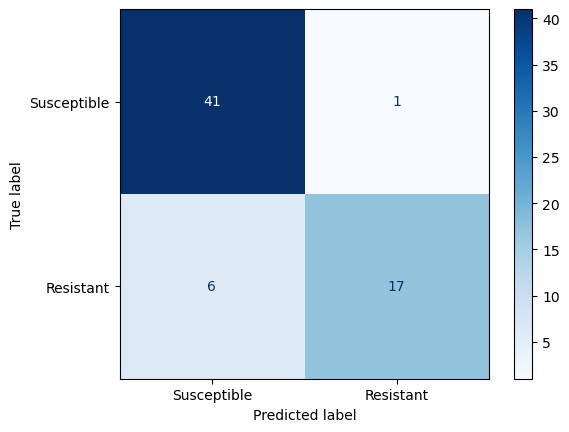

Confusion Matrix - Without Lineage (Best Params + Feature Reduction)


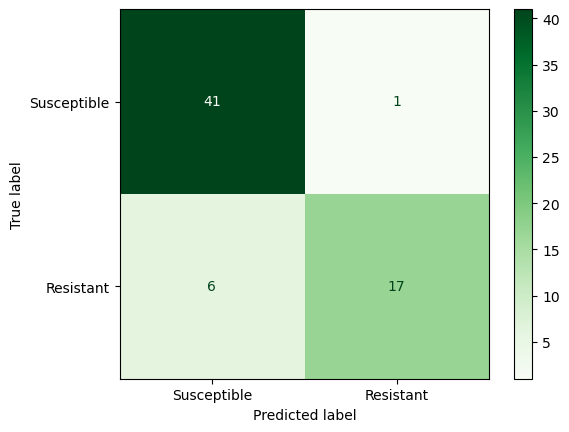

In [184]:
# With Lineage
cm_wi_best = confusion_matrix(y_test, y_pred_wi_best)
disp_wi_best = ConfusionMatrixDisplay(confusion_matrix=cm_wi_best, display_labels=["Susceptible", "Resistant"])
print("Confusion Matrix - With Lineage (Best Params + Feature Reduction)")
disp_wi_best.plot(cmap="Blues")
plt.grid(False)
plt.show()

# Without Lineage
cm_wo_best = confusion_matrix(y_test, y_pred_wo_best)
disp_wo_best = ConfusionMatrixDisplay(confusion_matrix=cm_wo_best, display_labels=["Susceptible", "Resistant"])
print("Confusion Matrix - Without Lineage (Best Params + Feature Reduction)")
disp_wo_best.plot(cmap="Greens")
plt.grid(False)
plt.show()

### Rifampicin resistance prediction

In [188]:
input_df = pd.read_csv("0_input_with_lineage.csv")
input_df = input_df.drop(columns=['id'], errors='ignore')

RIF_na = input_df['rifampicin_resistance'].isna().sum()
print("Missing values before drop:", RIF_na)

# drop rows where resistance is missing
input_df = input_df.dropna(subset=['rifampicin_resistance'])
input_df = pd.get_dummies(input_df, columns=['country'])

Missing values before drop: 55


In [190]:
columns_to_drop = ['isoniazid_resistance', 'ethambutol_resistance', 'streptomycin_resistance']
input_df = input_df.drop(columns=columns_to_drop, errors='ignore')

# convert float to int
input_df['rifampicin_resistance'] = input_df['rifampicin_resistance'].astype(int)

In [192]:
print("Shape after drop:", input_df.shape)

Shape after drop: (325, 118)


#### Training

In [197]:
X_with_lineage = input_df.drop(columns=['rifampicin_resistance'])
X_without_lineage = X_with_lineage.drop(columns=[col for col in X_with_lineage.columns if 'lineage' in col.lower()], errors='ignore')
y = input_df['rifampicin_resistance']

print("Shape of X_with_lineage (features):", X_with_lineage.shape)
print("Shape of X_without_lineage (features):", X_without_lineage.shape)
print("Shape of y (target):", y.shape)

Shape of X_with_lineage (features): (325, 117)
Shape of X_without_lineage (features): (325, 116)
Shape of y (target): (325,)


In [199]:
X_train_wi, X_test_wi, y_train, y_test = train_test_split(X_with_lineage, y, test_size=0.2, random_state=42, stratify=y)
X_train_wo, X_test_wo, _, _ = train_test_split(X_without_lineage, y, test_size=0.2, random_state=42, stratify=y)

In [201]:
print("=== Original Feature Shapes ===")
print("Shape of X_with_lineage:", X_with_lineage.shape)
print("Shape of X_without_lineage:", X_without_lineage.shape)
print("Shape of y (target):", y.shape)

print("\n=== Train/Test Split Shapes (without lineage) ===")
print("Training feature shape:", X_train_wo.shape)
print("Testing feature shape:", X_test_wo.shape)

print("\n=== Train/Test Split Shapes (with lineage) ===")
print("Training feature shape:", X_train_wi.shape)
print("Testing feature shape:", X_test_wi.shape)

=== Original Feature Shapes ===
Shape of X_with_lineage: (325, 117)
Shape of X_without_lineage: (325, 116)
Shape of y (target): (325,)

=== Train/Test Split Shapes (without lineage) ===
Training feature shape: (260, 116)
Testing feature shape: (65, 116)

=== Train/Test Split Shapes (with lineage) ===
Training feature shape: (260, 117)
Testing feature shape: (65, 117)


In [211]:
# === Cross-validation WITH lineage ===
rf_wi = RandomForestClassifier(random_state=42)
scores_wi = cross_validate(rf_wi, X_with_lineage, y, cv=5,
                           scoring=['accuracy', 'precision', 'recall', 'f1'])

# === Cross-validation WITHOUT lineage ===
rf_wo = RandomForestClassifier(random_state=42)
scores_wo = cross_validate(rf_wo, X_without_lineage, y, cv=5,
                           scoring=['accuracy', 'precision', 'recall', 'f1'])

# === Collect CV Results ===
cv_results = []

cv_results.append({
    "Drug": "RIF",
    "Model": "With Lineage",
    "Accuracy": np.mean(scores_wi['test_accuracy']),
    "Precision": np.mean(scores_wi['test_precision']),
    "Recall": np.mean(scores_wi['test_recall']),
    "F1 Score": np.mean(scores_wi['test_f1']),
})

cv_results.append({
    "Drug": "RIF",
    "Model": "Without Lineage",
    "Accuracy": np.mean(scores_wo['test_accuracy']),
    "Precision": np.mean(scores_wo['test_precision']),
    "Recall": np.mean(scores_wo['test_recall']),
    "F1 Score": np.mean(scores_wo['test_f1']),
})

In [212]:
# === Test WITH lineage ===
rf_wi_test = RandomForestClassifier(random_state=42)
rf_wi_test.fit(X_train_wi, y_train)
y_pred_wi = rf_wi_test.predict(X_test_wi)

cv_results.append({
    "Drug": "RIF",
    "Model": "With Lineage (Test)",
    "Accuracy": accuracy_score(y_test, y_pred_wi),
    "Precision": precision_score(y_test, y_pred_wi),
    "Recall": recall_score(y_test, y_pred_wi),
    "F1 Score": f1_score(y_test, y_pred_wi),
})

# === Test WITHOUT lineage ===
rf_wo_test = RandomForestClassifier(random_state=42)
rf_wo_test.fit(X_train_wo, y_train)
y_pred_wo = rf_wo_test.predict(X_test_wo)

cv_results.append({
    "Drug": "RIF",
    "Model": "Without Lineage (Test)",
    "Accuracy": accuracy_score(y_test, y_pred_wo),
    "Precision": precision_score(y_test, y_pred_wo),
    "Recall": recall_score(y_test, y_pred_wo),
    "F1 Score": f1_score(y_test, y_pred_wo),
})


#### Performance metrics

In [216]:
results_df = pd.DataFrame(cv_results)
results_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']] = results_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']].round(2)
results_df

,Drug,Model,Accuracy,Precision,Recall,F1 Score
0,RIF,With Lineage,0.89,0.83,0.79,0.81
1,RIF,Without Lineage,0.88,0.83,0.74,0.78
2,RIF,With Lineage (Test),0.86,0.80,0.67,0.73
3,RIF,Without Lineage (Test),0.86,0.85,0.61,0.71


Confusion Matrix - With Lineage (Test)


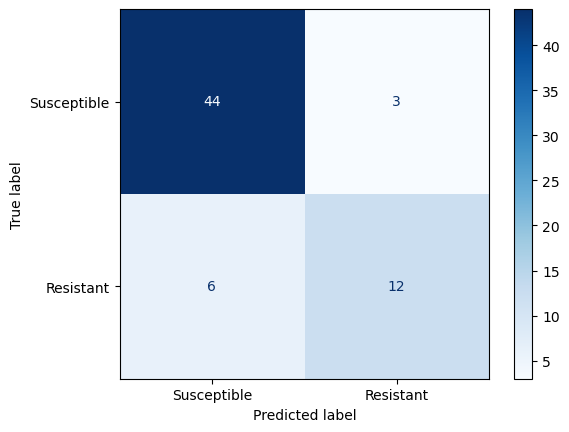

Confusion Matrix - Without Lineage (Test)


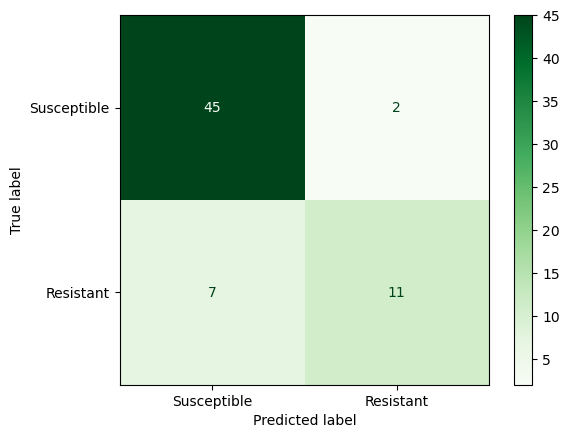

In [218]:
# === Confusion Matrix for With Lineage ===
cm_wi = confusion_matrix(y_test, y_pred_wi)
disp_wi = ConfusionMatrixDisplay(confusion_matrix=cm_wi, display_labels=["Susceptible", "Resistant"])
print("Confusion Matrix - With Lineage (Test)")
disp_wi.plot(cmap="Blues")
plt.grid(False)
plt.show()

# === Confusion Matrix for Without Lineage ===
cm_wo = confusion_matrix(y_test, y_pred_wo)
disp_wo = ConfusionMatrixDisplay(confusion_matrix=cm_wo, display_labels=["Susceptible", "Resistant"])
print("Confusion Matrix - Without Lineage (Test)")
disp_wo.plot(cmap="Greens")
plt.grid(False)
plt.show()


=== Decision Trees from Random Forest (With Lineage) ===


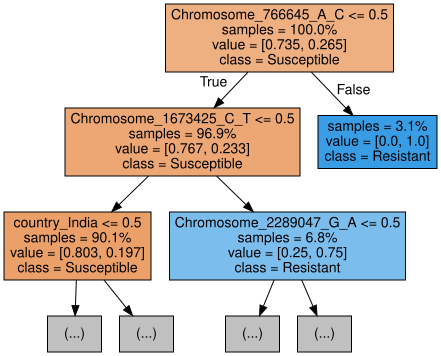

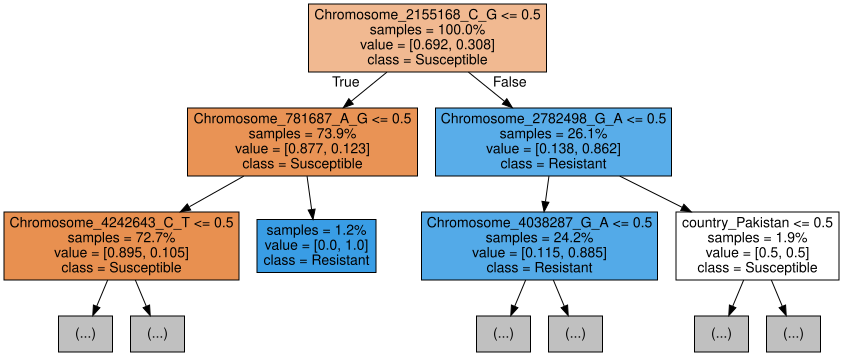

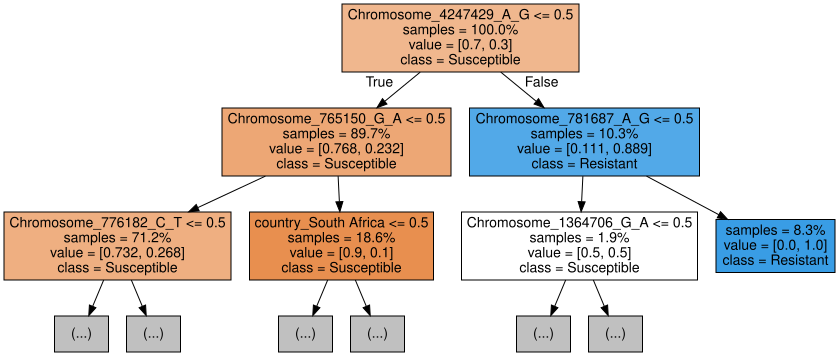


=== Decision Trees from Random Forest (Without Lineage) ===


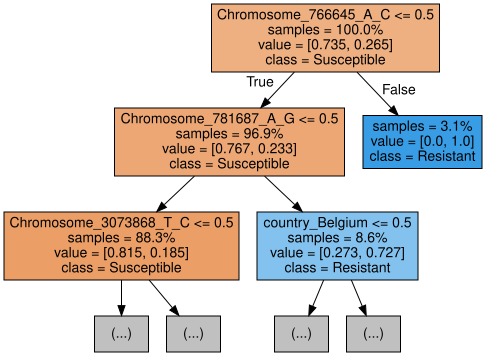

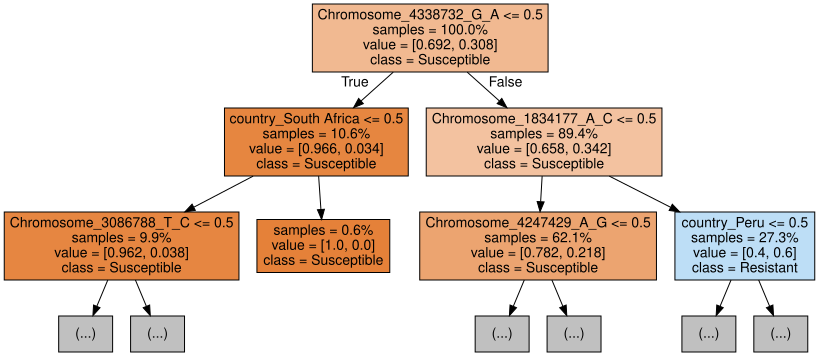

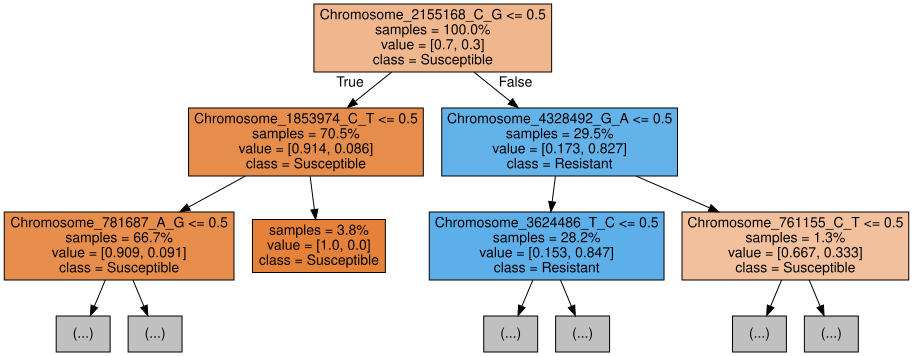

In [220]:
# === Visualize 3 Trees from Random Forest (With Lineage)
print("=== Decision Trees from Random Forest (With Lineage) ===")
for i in range(3):
    tree = rf_wi_test.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X_train_wi.columns,
                               filled=True,
                               max_depth=2,
                               impurity=False,
                               proportion=True,
                               class_names=["Susceptible", "Resistant"])
    graph = graphviz.Source(dot_data)
    display(graph)
    graph.render(f"tree_with_lineage_{i}", format="png", cleanup=True)

# === Visualize 3 Trees from Random Forest (Without Lineage)
print("\n=== Decision Trees from Random Forest (Without Lineage) ===")
for i in range(3):
    tree = rf_wo_test.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X_train_wo.columns,
                               filled=True,
                               max_depth=2,
                               impurity=False,
                               proportion=True,
                               class_names=["Susceptible", "Resistant"])
    graph = graphviz.Source(dot_data)
    display(graph)
    graph.render(f"tree_without_lineage_{i}", format="png", cleanup=True)


## Ethambutol Resistance

In [223]:
input_df = pd.read_csv("0_input_with_lineage.csv")
input_df = input_df.drop(columns=['id'], errors='ignore')

EMB_na = input_df['ethambutol_resistance'].isna().sum()
print("Missing values before drop:", EMB_na)

# drop rows where resistance is missing
input_df = input_df.dropna(subset=['ethambutol_resistance'])
input_df = pd.get_dummies(input_df, columns=['country'])

Missing values before drop: 101


In [225]:
columns_to_drop = ['rifampicin_resistance', 'isoniazid_resistance', 'streptomycin_resistance']
input_df = input_df.drop(columns=columns_to_drop, errors='ignore')

# convert float to int
input_df['ethambutol_resistance'] = input_df['ethambutol_resistance'].astype(int)

In [227]:
print("Shape after drop:", input_df.shape)

Shape after drop: (279, 118)


#### Training

In [230]:
X_with_lineage = input_df.drop(columns=['ethambutol_resistance'])
X_without_lineage = X_with_lineage.drop(columns=[col for col in X_with_lineage.columns if 'lineage' in col.lower()], errors='ignore')
y = input_df['ethambutol_resistance']

print("Shape of X_with_lineage (features):", X_with_lineage.shape)
print("Shape of X_without_lineage (features):", X_without_lineage.shape)
print("Shape of y (target):", y.shape)

Shape of X_with_lineage (features): (279, 117)
Shape of X_without_lineage (features): (279, 116)
Shape of y (target): (279,)


In [232]:
X_train_wi, X_test_wi, y_train, y_test = train_test_split(X_with_lineage, y, test_size=0.2, random_state=42, stratify=y)
X_train_wo, X_test_wo, _, _ = train_test_split(X_without_lineage, y, test_size=0.2, random_state=42, stratify=y)

In [234]:
print("=== Original Feature Shapes ===")
print("Shape of X_with_lineage:", X_with_lineage.shape)
print("Shape of X_without_lineage:", X_without_lineage.shape)
print("Shape of y (target):", y.shape)

print("\n=== Train/Test Split Shapes (without lineage) ===")
print("Training feature shape:", X_train_wo.shape)
print("Testing feature shape:", X_test_wo.shape)

print("\n=== Train/Test Split Shapes (with lineage) ===")
print("Training feature shape:", X_train_wi.shape)
print("Testing feature shape:", X_test_wi.shape)

=== Original Feature Shapes ===
Shape of X_with_lineage: (279, 117)
Shape of X_without_lineage: (279, 116)
Shape of y (target): (279,)

=== Train/Test Split Shapes (without lineage) ===
Training feature shape: (223, 116)
Testing feature shape: (56, 116)

=== Train/Test Split Shapes (with lineage) ===
Training feature shape: (223, 117)
Testing feature shape: (56, 117)


In [249]:
# === Cross-validation WITH lineage ===
rf_wi = RandomForestClassifier(random_state=42)
scores_wi = cross_validate(rf_wi, X_with_lineage, y, cv=5,
                           scoring=['accuracy', 'precision', 'recall', 'f1'])

# === Cross-validation WITHOUT lineage ===
rf_wo = RandomForestClassifier(random_state=42)
scores_wo = cross_validate(rf_wo, X_without_lineage, y, cv=5,
                           scoring=['accuracy', 'precision', 'recall', 'f1'])

# === Collect CV Results ===
cv_results = []

cv_results.append({
    "Drug": "EMB",
    "Model": "With Lineage",
    "Accuracy": np.mean(scores_wi['test_accuracy']),
    "Precision": np.mean(scores_wi['test_precision']),
    "Recall": np.mean(scores_wi['test_recall']),
    "F1 Score": np.mean(scores_wi['test_f1']),
})

cv_results.append({
    "Drug": "EMB",
    "Model": "Without Lineage",
    "Accuracy": np.mean(scores_wo['test_accuracy']),
    "Precision": np.mean(scores_wo['test_precision']),
    "Recall": np.mean(scores_wo['test_recall']),
    "F1 Score": np.mean(scores_wo['test_f1']),
})

In [250]:
# === Test WITH lineage ===
rf_wi_test = RandomForestClassifier(random_state=42)
rf_wi_test.fit(X_train_wi, y_train)
y_pred_wi = rf_wi_test.predict(X_test_wi)

cv_results.append({
    "Drug": "EMB",
    "Model": "With Lineage (Test)",
    "Accuracy": accuracy_score(y_test, y_pred_wi),
    "Precision": precision_score(y_test, y_pred_wi),
    "Recall": recall_score(y_test, y_pred_wi),
    "F1 Score": f1_score(y_test, y_pred_wi),
})

# === Test WITHOUT lineage ===
rf_wo_test = RandomForestClassifier(random_state=42)
rf_wo_test.fit(X_train_wo, y_train)
y_pred_wo = rf_wo_test.predict(X_test_wo)

cv_results.append({
    "Drug": "EMB",
    "Model": "Without Lineage (Test)",
    "Accuracy": accuracy_score(y_test, y_pred_wo),
    "Precision": precision_score(y_test, y_pred_wo),
    "Recall": recall_score(y_test, y_pred_wo),
    "F1 Score": f1_score(y_test, y_pred_wo),
})

#### Performance metrics

In [256]:
results_df = pd.DataFrame(cv_results)
results_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']] = results_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']].round(2)
results_df

,Drug,Model,Accuracy,Precision,Recall,F1 Score
0,EMB,With Lineage,0.87,0.69,0.43,0.50
1,EMB,Without Lineage,0.87,0.70,0.45,0.52
2,EMB,With Lineage (Test),0.86,0.60,0.33,0.43
3,EMB,Without Lineage (Test),0.86,0.60,0.33,0.43


Confusion Matrix - With Lineage (Test)


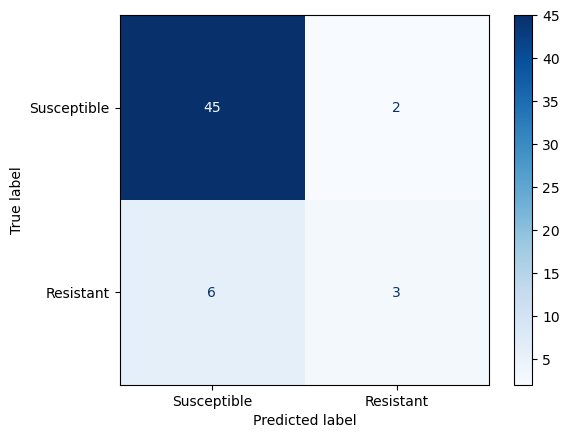

Confusion Matrix - Without Lineage (Test)


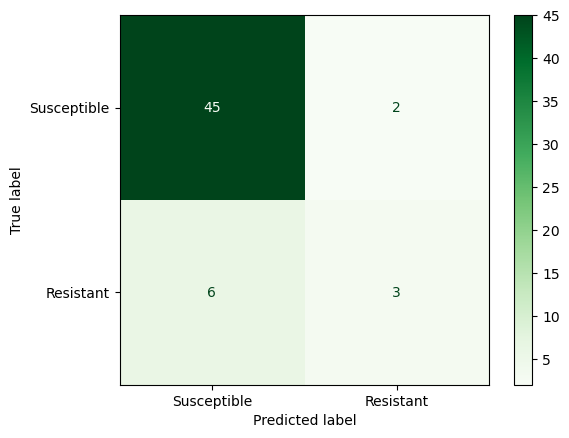

In [247]:
# === Confusion Matrix for With Lineage ===
cm_wi = confusion_matrix(y_test, y_pred_wi)
disp_wi = ConfusionMatrixDisplay(confusion_matrix=cm_wi, display_labels=["Susceptible", "Resistant"])
print("Confusion Matrix - With Lineage (Test)")
disp_wi.plot(cmap="Blues")
plt.grid(False)
plt.show()

# === Confusion Matrix for Without Lineage ===
cm_wo = confusion_matrix(y_test, y_pred_wo)
disp_wo = ConfusionMatrixDisplay(confusion_matrix=cm_wo, display_labels=["Susceptible", "Resistant"])
print("Confusion Matrix - Without Lineage (Test)")
disp_wo.plot(cmap="Greens")
plt.grid(False)
plt.show()

## Streptomycin Resistance

In [258]:
input_df = pd.read_csv("0_input_with_lineage.csv")
input_df = input_df.drop(columns=['id'], errors='ignore')

STM_na = input_df['streptomycin_resistance'].isna().sum()
print("Missing values before drop:", STM_na)

# drop rows where resistance is missing
input_df = input_df.dropna(subset=['streptomycin_resistance'])
input_df = pd.get_dummies(input_df, columns=['country'])

Missing values before drop: 281


majority are missing - skipping

END